In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import noisereduce as nr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib



In [3]:
dataset_path = "C:/Users/mosta/OneDrive/Desktop/ML/BabyCries"
folders = os.listdir(dataset_path)

recordings=[]
labels=[]

for label in folders:
    label_path = os.path.join(dataset_path,label)
    
    for file in os.listdir(label_path):
        recordings.append(os.path.join(label_path,file))
        labels.append(label)


data = pd.DataFrame({
    "file": recordings,
    "label": labels
})

print(data["label"].value_counts())

label
hungry        382
discomfort     27
tired          24
Name: count, dtype: int64


In [4]:
#splitting
train_data, test_data = train_test_split( data ,test_size= 0.2, random_state=42 ,   stratify=data["label"])
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42, stratify=train_data["label"])
print("Training data=", len(train_data))
print("Validation samples =", len(val_data))
print("Testing data=", len(test_data))

Training data= 276
Validation samples = 70
Testing data= 87


In [5]:
#augmentation

# def augment_rec (y,sr):
#     augmented_samples =[]

#     #pitch
#     augmented_samples.append (librosa.effects.pitch_shift(y=y, sr=sr,n_steps=2))
#     augmented_samples.append (librosa.effects.pitch_shift(y=y, sr=sr,n_steps=-2))

#     #time stretch
#     augmented_samples.append(librosa.effects.time_stretch(y=y,rate=0.9))
#     augmented_samples.append(librosa.effects.time_stretch(y=y,rate=1.1))

#     #adding noise
#     noise = np.random.normal( 0,0.005,len(y))
#     augmented_samples.append(y+ noise)

#     return augmented_samples
    

def augment_rec (y,sr):
    augmented_samples =[]

    #pitch
    for steps in (-5,-4,-3,-2,-1,1,2,3,4,5):
        augmented_samples.append(librosa.effects.pitch_shift(y=y, sr=sr,n_steps=steps))

    #time
    for rate in (0.9,0.95,1.05,1.1,1.15,1.2,1.25,1.3):
        augmented_samples.append(librosa.effects.time_stretch(y= y,rate=rate))

    #noise 
    for scale in(0.002,0.005,0.01,0.015,0.018,0.02):
        noise =np.random.normal(0,scale, len(y))
        augmented_samples.append(y+noise)

    return augmented_samples



In [6]:

train_audio =[]

for _, row in train_data.iterrows():
    file_path = row["file"]
    label = row["label"]

    y,sr =librosa.load( file_path, sr=16000)
    train_audio.append((y,label))

    if (row["label"]!="hungry"):
        augmented = augment_rec(y,sr)
        for audio in augmented:
            train_audio.append((audio,label))

print("Number after augmentation:")
print(pd.Series([label for _, label in train_audio]).value_counts())

c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(


Number after augmentation:
discomfort    450
tired         375
hungry        243
Name: count, dtype: int64


In [7]:
#cleaning audio:

def clean_audio(y,sr):
    y_clean =nr.reduce_noise( y=y ,sr =sr)#stage 1 (noise reduction)

#stage 2 (sound detection using RMS ,because webrtcvad library and VAD libraries in general arent working)

#dividing into audio frames,frame size=20ms
    frame_duration=0.02
    frame_length = int(sr*frame_duration)
    sound_frames=[]
    threshold=0.02
    for i in range (0, len(y_clean),frame_length):
        frame = y_clean[i:i + frame_length]
        if len(frame)==0:
            continue
        rms = np.sqrt(np.mean(frame**2))
        if rms>threshold:
            sound_frames.append(frame)

    if len(sound_frames)==0:
        return np.array([])

    y_clean= np.concatenate(sound_frames)

    return y_clean


In [8]:
#features extraction
def extract_features(y,sr):
    features=[]

    mfcc= librosa.feature.mfcc(y=y, sr=sr,n_mfcc=13)
    mfcc_mean=np.mean(mfcc,axis=1)
    mfcc_std=np.std(mfcc,axis=1)
    features.extend(mfcc_mean) 
    features.extend(mfcc_std)

    duration=len(y)/sr
    features.append(duration)
    
    zcr_mean= np.mean(librosa.feature.zero_crossing_rate(y=y))
    features.append(zcr_mean)
    
    rms_mean= np.mean(librosa.feature.rms(y=y))
    features.append(rms_mean)
    
    f0=librosa.yin(y, fmin=300,fmax=600,sr=sr) 
    f0= f0[~np.isnan(f0)]
    if len(f0)>0: 
        pitch_mean= np.mean(f0)
    else: pitch_mean = 0 
    features.append(pitch_mean)
    
    return features




In [9]:
x_train=[]
y_train=[]
for y,label in train_audio:
    cleaned= clean_audio(y,16000)
    if cleaned is None or len(cleaned)==0:
        continue
    features=extract_features(cleaned,16000)
    x_train.append(features)
    y_train.append(label)
x_train=np.array(x_train)
y_train=np.array(y_train)

print("x_train shape =",x_train.shape) 
print("y_train shape =",y_train.shape)
print(pd.Series(y_train).value_counts())

c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=320
  stft(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1920
  stft(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1280
  stft(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1600
  stft(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=960
  stft(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py

x_train shape = (949, 30)
y_train shape = (949,)
discomfort    393
tired         326
hungry        230
Name: count, dtype: int64


In [10]:
x_val=[]
y_val= []

for _, row in val_data.iterrows():
    y,sr= librosa.load(row['file'],sr=16000)
    cleaned =clean_audio(y, sr)
    if len(cleaned)==0:
        continue
    features= extract_features(cleaned,sr)
    x_val.append(features)
    y_val.append(row["label"])

x_val=np.array(x_val)
y_val=np.array(y_val)

print("X_val shape =", x_val.shape)

X_val shape = (65, 30)


In [11]:
x_test=[]
y_test=[]
for _, row in test_data.iterrows():
    file_path= row['file']
    label=row["label"]
    y,sr= librosa.load(file_path, sr=16000)
    cleaned=clean_audio(y,sr)
    if len(cleaned)==0:
        continue
    features=extract_features(cleaned,sr)
    x_test.append(features)
    y_test.append(label)

x_test=np.array(x_test)
y_test=np.array(y_test)
print("X_test shape =", x_test.shape) 
print("y_test shape =", y_test.shape)
print(pd.Series(y_test).value_counts())

c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1920
  stft(
c:\Users\mosta\AppData\Local\Programs\Python\Python314\Lib\site-packages\librosa\core\spectrum.py:3004: UserWarning: n_fft=2048 is too large for input signal of length=1600
  stft(


X_test shape = (86, 30)
y_test shape = (86,)
hungry        77
discomfort     5
tired          4
Name: count, dtype: int64


In [12]:
#training
model= RandomForestClassifier(n_estimators=200 ,random_state=42,class_weight="balanced")
model.fit(x_train,y_train)
print(x_train.shape)
print(x_test.shape)


(949, 30)
(86, 30)


In [13]:
val_preds= model.predict(x_val)
print("Validation results")
print("Validation Accuracy=",accuracy_score(y_val,val_preds))
print(classification_report(y_val,val_preds))

Validation results
Validation Accuracy= 0.7846153846153846
              precision    recall  f1-score   support

  discomfort       0.14      0.25      0.18         4
      hungry       0.89      0.88      0.88        57
       tired       0.00      0.00      0.00         4

    accuracy                           0.78        65
   macro avg       0.35      0.38      0.36        65
weighted avg       0.79      0.78      0.79        65



In [14]:
# #training
# model =RandomForestClassifier(
#     n_estimators=50,
#     random_state=42,
#     class_weight="balanced",
#     warm_start=True
# )

# best_accuracy=0
# best_n_estimators=50

# for n in [50, 100, 150, 200, 250, 300]:

#     model.n_estimators = n
#     model.fit(x_train, y_train)

#     val_preds = model.predict(x_val)
#     val_accuracy = accuracy_score(y_val, val_preds)

#     print("n_estimators =", n)
#     print("Validation Accuracy =", val_accuracy)

#     if val_accuracy > best_accuracy:
#         best_accuracy = val_accuracy
#         best_n_estimators = n

# print("Best n_estimators =", best_n_estimators)
# print("Best Validation Accuracy =", best_accuracy)

# model = RandomForestClassifier(
#     n_estimators=best_n_estimators,
#     random_state=42,
#     class_weight="balanced"
# )

# model.fit(x_train, y_train)

In [15]:
train_preds = model.predict(x_train)
print("Training Accuracy =", accuracy_score(y_train, train_preds))

Training Accuracy = 1.0


In [16]:
#testing
y_pred= model.predict(x_test)

In [17]:
# #testing
# #using threshold tuning to fix the model confusion
# probs=model.predict_proba(x_test)
# y_pred=[]
# threshold2= 0.3

# for prob in probs:
#     discomfort_prob=prob[list(model.classes_).index("discomfort")]
#     hungry_prob=prob[list(model.classes_).index("hungry")]
#     tired_prob=prob[list(model.classes_).index("tired")]
#     if tired_prob>=threshold2: 
#         prediction="tired"

#     elif discomfort_prob>=threshold2: 
#         prediction="discomfort"

#     else:
#         prediction="hungry"

#     y_pred.append(prediction)
# y_pred=np.array(y_pred)

In [18]:
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy= ",accuracy)

Accuracy=  0.7209302325581395


confusion matrix= 
[[ 1  4  0]
 [10 60  7]
 [ 1  2  1]]


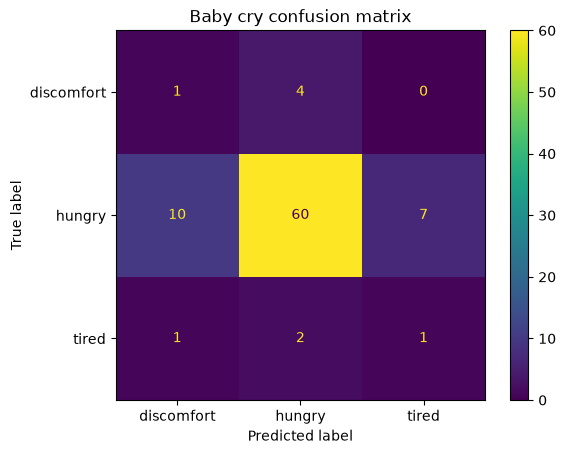

              precision    recall  f1-score   support

  discomfort       0.08      0.20      0.12         5
      hungry       0.91      0.78      0.84        77
       tired       0.12      0.25      0.17         4

    accuracy                           0.72        86
   macro avg       0.37      0.41      0.37        86
weighted avg       0.82      0.72      0.77        86



In [19]:
cm= confusion_matrix(y_test,y_pred)
print("confusion matrix= ")
print(cm)
disp = ConfusionMatrixDisplay( confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.title("Baby cry confusion matrix")
plt.show()
print(classification_report(y_test, y_pred))

In [23]:
joblib.dump(model,"BabyCry_model.pkl")

['BabyCry_model.pkl']